# Decision Tree

## 1. Importing Necessary packages

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve

## 2. Importing Dataset

In [2]:
claimants_data = pd.read_csv("claimants.csv")
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## 3. Data Understanding

In [4]:
claimants_data.shape

(1340, 7)

In [5]:
claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [7]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

## 4. Data Prepartion

### 4.1 Data Cleaning

In [8]:
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [3]:
claimants_data.dropna(inplace=True)
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [11]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

In [8]:
claimants_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

## 4.2 Separate Input and Output

In [13]:
# Input

In [4]:
X = claimants_data.drop(labels = ['CASENUM','ATTORNEY'],axis = 1)
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [15]:
# Output

In [5]:
y = claimants_data["ATTORNEY"]
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

## 5. Model building

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,shuffle=True, random_state= 45)

In [8]:
X_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
730,0.0,1.0,0.0,0.0,0.050
93,0.0,1.0,0.0,31.0,3.018
720,1.0,1.0,0.0,17.0,3.737
382,1.0,1.0,0.0,35.0,8.508
596,1.0,1.0,0.0,70.0,0.108
...,...,...,...,...,...
708,1.0,1.0,0.0,37.0,1.805
202,1.0,1.0,0.0,18.0,3.086
738,0.0,0.0,0.0,78.0,4.115
508,0.0,1.0,0.0,8.0,1.908


In [11]:
logistic_model = LogisticRegression()

## 6. Model Training

In [12]:
logistic_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [8]:
dt_model = DecisionTreeClassifier(max_depth=5)

In [9]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


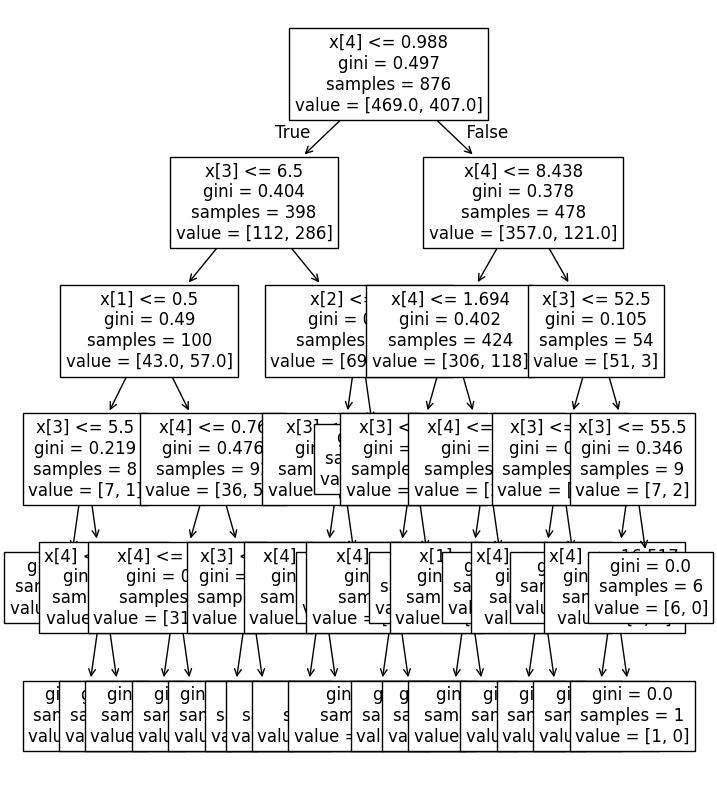

In [17]:
plt.figure(figsize=(8,10))
plot_tree(decision_tree = dt_model,fontsize=12)
plt.show()

## 7. Model Testing

### Training Data

In [44]:
y_pred_train = dt_model.predict(X_train)
y_pred_train

array([1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,

### Test Data

In [45]:
y_pred_test = dt_model.predict(X_test)
y_pred_test

array([1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1])

## 8. Model Evaluation

In [46]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, auc, roc_auc_score 

### 8.2 Train Data's Evaluation Metrics

In [47]:
print(confusion_matrix(y_train,y_pred_train))

[[372  97]
 [112 295]]


In [48]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78       469
           1       0.75      0.72      0.74       407

    accuracy                           0.76       876
   macro avg       0.76      0.76      0.76       876
weighted avg       0.76      0.76      0.76       876



## ROC Curve - Receiver Operating Characteristics

### AUC - Area Under the curve

In [49]:
fpr, tpr, thresholds = roc_curve(y_train, dt_model.predict_proba (X_train) [:,-1])

In [50]:
auc = roc_auc_score(y_train,y_pred_train)
print(auc)

0.7589963485485873


Text(0, 0.5, 'True Positive Rate')

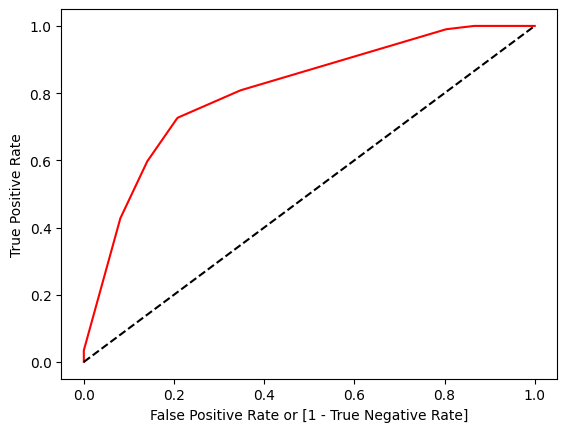

In [51]:
plt.plot(fpr, tpr, color= 'red', label = 'logic model(area = %0.2f)' %auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

## 8.3 Test Data's Evaluation Metrics

In [52]:
print(confusion_matrix(y_test,y_pred_test))

[[86 23]
 [38 73]]


In [53]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.69      0.79      0.74       109
           1       0.76      0.66      0.71       111

    accuracy                           0.72       220
   macro avg       0.73      0.72      0.72       220
weighted avg       0.73      0.72      0.72       220



## AUC and ROC Curve for Test Data

In [54]:
fpr, tpr, thresholds = roc_curve(y_test, dt_model.predict_proba (X_test) [:,-1])

In [55]:
auc = roc_auc_score(y_test,y_pred_test)
print(auc)

0.7233242416728655


Text(0, 0.5, 'True Positive Rate')

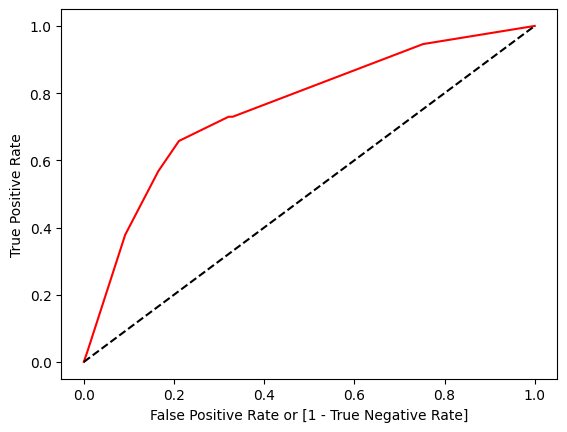

In [56]:
plt.plot(fpr, tpr, color= 'red', label = 'logic model(area = %0.2f)' %auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')